In [2]:

from pathlib import Path
import pandas as pd

PYTHON_ROOT = Path.home() / "Desktop" / "python"
PROJECT_DIR = (PYTHON_ROOT / "trading_portfolio" / "uk_portfolio" / "etf_relative_momentum")

for folder in ["data", "src", "tests"]:
    (PROJECT_DIR / folder).mkdir(parents=True, exist_ok=True)

EXPOSURES = {
    #equities
    "IUSA": "US large-cap equities",
    "ISF": "UK large-cap equities",
    "IEUX": "Europe ex-UK equities",
    "IJPN": "Japanese equities",
    "IEEM": "Emerging-market equities",
    "CPJ1": "Developed Pacific ex-Japan equities",
    "MIDD": "UK mid-cap equities",
    "WLDS": "Developed-world small-cap equities",

    #gov bonds
    "IGLS": "UK gilts: 0-5 years",
    "IGLT": "UK gilts: all maturities",
    "GLTL": "UK gilts: 15+ years",
    "INXG": "UK inflation-linked gilts",
    "IGTM": "US Treasuries: 7-10 years, GBP hedged",
    "XGSG": "Global government bonds, GBP hedged",

    #corporate bonds
    "SLXX": "Sterling investment-grade corporate bonds",
    "CRHG": "Global investment-grade corporate bonds, GBP hedged",
    "GHYS": "Global high-yield corporate bonds, GBP hedged",

    #property and commodities
    "IWDP": "Developed-market listed property",
    "SGLN": "Physical gold",
    "CMOP": "Broad commodity futures",
}

universe_path = PROJECT_DIR / "data" / "candidate_universe_v2.csv"

if universe_path.exists():

    universe = pd.read_csv(
        universe_path, dtype=str, keep_default_na=False
    ).set_index("ticker", verify_integrity=True)
else:
    catalogue = pd.read_csv(
        PYTHON_ROOT / "t212_universe" / "t212_live_universe.csv",
        dtype=str,
        keep_default_na=False,
    )

    universe = (
        catalogue.loc[catalogue["ticker"].isin(EXPOSURES)]
        .set_index("ticker", verify_integrity=True)
        .loc[list(EXPOSURES)]
        .copy()
    )

    # Keep the original catalogue classifications alongside our labels.
    universe["research_exposure"] = pd.Series(EXPOSURES)



assert universe.index.tolist() == list(EXPOSURES)
assert universe["research_exposure"].to_dict() == EXPOSURES
assert universe["isin"].is_unique
assert universe["live_eligible"].eq("true").all()
assert universe["api_currency"].isin(["GBP", "GBX"]).all()

if not universe_path.exists():
    universe.to_csv(universe_path)

print(f"Saved research candidates: {len(universe)}")

display(universe[[
    "yf_symbol",
    "research_exposure",
    "api_currency",
    "api_snapshot",
]])

Saved research candidates: 20


,yf_symbol,research_exposure,api_currency,api_snapshot
ticker,,,,
IUSA,IUSA.L,US large-cap equities,GBX,2026-09-23-api
ISF,ISF.L,UK large-cap equities,GBX,2026-09-23-api
IEUX,IEUX.L,Europe ex-UK equities,GBX,2026-09-23-api
IJPN,IJPN.L,Japanese equities,GBX,2026-09-23-api
IEEM,IEEM.L,Emerging-market equities,GBX,2026-09-23-api
CPJ1,CPJ1.L,Developed Pacific ex-Japan equities,GBX,2026-09-23-api
MIDD,MIDD.L,UK mid-cap equities,GBX,2026-09-23-api
WLDS,WLDS.L,Developed-world small-cap equities,GBP,2026-09-23-api
IGLS,IGLS.L,UK gilts: 0-5 years,GBP,2026-09-23-api


In [3]:
quote_units = universe[[
    "yf_symbol", "api_currency", "unit_divisor_to_gbp"
]].copy()

quote_units["unit_divisor_to_gbp"] = pd.to_numeric(
    quote_units["unit_divisor_to_gbp"],
    errors="raise",
)

expected_divisors = quote_units["api_currency"].map({
    "GBP": 1,
    "GBX": 100,
})

assert quote_units["unit_divisor_to_gbp"].eq(expected_divisors).all()

display(quote_units)

,yf_symbol,api_currency,unit_divisor_to_gbp
ticker,,,
IUSA,IUSA.L,GBX,100
ISF,ISF.L,GBX,100
IEUX,IEUX.L,GBX,100
IJPN,IJPN.L,GBX,100
IEEM,IEEM.L,GBX,100
CPJ1,CPJ1.L,GBX,100
MIDD,MIDD.L,GBX,100
WLDS,WLDS.L,GBP,1
IGLS,IGLS.L,GBP,1


In [ ]:
import shutil
import sys

TREND_DIR = PROJECT_DIR.parent / "etf_trend"
trend_src = str(TREND_DIR / "src")

if trend_src not in sys.path:
    sys.path.insert(0, trend_src)

import etf_data

DATA_START = "2000-01-01"
DATA_END = "2026-09-01"  #exclusive
RAW_DIR = PROJECT_DIR / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

histories = {}
history_metadata = {}

for ticker, row in universe.iterrows():
    symbol = row["yf_symbol"]
    stem = f"{symbol}_{DATA_START}_{DATA_END}_raw"

    old_pair = [
        TREND_DIR / "data" / "raw" / f"{stem}.{suffix}"
        for suffix in ("csv", "json")
    ]
    new_pair = [
        RAW_DIR / f"{stem}.{suffix}"
        for suffix in ("csv", "json")
    ]

    present = [path.exists() for path in new_pair]

    if any(present) and not all(present):
        raise ValueError(f"{ticker}: incomplete cache pair in {RAW_DIR}")

    if not any(present) and all(path.exists() for path in old_pair):
        for source, destination in zip(old_pair, new_pair):
            shutil.copy2(source, destination)

    print(f"Loading {ticker} ({symbol})...", flush=True)

    prices, metadata = etf_data.load_etf_history(
        symbol,
        DATA_START,
        DATA_END,
        RAW_DIR,
        refresh=False,
        repair=False,
    )

    histories[ticker] = prices
    history_metadata[ticker] = metadata

history_coverage = pd.DataFrame([
    {
        "ticker": ticker,
        "first_date": prices.index.min(),
        "last_date": prices.index.max(),
        "rows": len(prices),
        "yahoo_currency": history_metadata[ticker].get("currency"),
        "catalogue_currency": universe.loc[ticker, "api_currency"],
    }
    for ticker, prices in histories.items()
]).set_index("ticker")

display(history_coverage)

Loading IUSA (IUSA.L)...
Loading ISF (ISF.L)...
Loading IEUX (IEUX.L)...
Loading IJPN (IJPN.L)...
Loading IEEM (IEEM.L)...
Loading CPJ1 (CPJ1.L)...
Loading MIDD (MIDD.L)...
Loading WLDS (WLDS.L)...
Loading IGLS (IGLS.L)...
Loading IGLT (IGLT.L)...
Loading GLTL (GLTL.L)...
Loading INXG (INXG.L)...
Loading IGTM (IGTM.L)...
Loading XGSG (XGSG.L)...
Loading SLXX (SLXX.L)...
Loading CRHG (CRHG.L)...
Loading GHYS (GHYS.L)...
Loading IWDP (IWDP.L)...
Loading SGLN (SGLN.L)...
Loading CMOP (CMOP.L)...


/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


,first_date,last_date,rows,yahoo_currency,catalogue_currency
ticker,,,,,
IUSA,2009-01-02,2026-08-28,4461,GBp,GBX
ISF,2009-01-02,2026-08-28,4461,GBp,GBX
IEUX,2009-01-02,2026-08-28,4461,GBp,GBX
IJPN,2009-01-02,2026-08-28,4461,GBp,GBX
IEEM,2009-01-02,2026-08-28,4461,GBp,GBX
CPJ1,2010-01-12,2026-08-28,4202,GBp,GBX
MIDD,2009-01-02,2026-08-28,4461,GBp,GBX
WLDS,2018-03-27,2026-08-28,2128,GBP,GBP
IGLS,2009-04-17,2026-08-28,4388,GBP,GBP


In [ ]:
import numpy as np

schedule = etf_data.build_lse_schedule(DATA_START, DATA_END)
audit_rows = []

for ticker, prices in histories.items():
    result = etf_data.audit_etf_history(prices).to_dict()

    #check coverage within this funds history
    expected_sessions = schedule.loc[
        prices.index.min():prices.index.max()
    ].index

    price_columns = prices[["Open", "High", "Low", "Close", "Adj Close"]]
    invalid_prices = price_columns.notna() & (
        price_columns.le(0) | ~np.isfinite(price_columns)
    )

    result.update({
        "ticker": ticker,
        "invalid_price_rows": int(invalid_prices.any(axis=1).sum()),
        "missing_sessions": len(
            expected_sessions.difference(prices.index)
        ),
        "off_calendar_rows": len(
            prices.index.difference(schedule.index)
        ),
    })

    audit_rows.append(result)

raw_audit = pd.DataFrame(audit_rows).set_index("ticker")
display(raw_audit.round(4))

,duplicate_dates,incomplete_price_rows,zero_volume_rows,large_close_moves,dividend_events,first_dividend_date,median_adjustment_ratio,invalid_price_rows,missing_sessions,off_calendar_rows
ticker,,,,,,,,,,
IUSA,0,2,4,0,50,2014-02-26,0.01,0,1,1
ISF,0,1,2,0,54,2013-02-20,0.01,0,1,1
IEUX,0,2,6,0,50,2014-02-26,0.01,0,1,1
IJPN,0,1,7,2,26,2014-05-21,0.01,0,1,1
IEEM,0,2,3,0,50,2014-02-26,0.01,0,1,1
CPJ1,0,2,982,3,0,NaT,NaN,0,1,1
MIDD,0,1,4,0,54,2013-02-20,0.01,0,1,1
WLDS,0,1,71,3,0,NaT,NaN,0,0,0
IGLS,0,0,7,0,27,2013-06-26,1.00,1,1,1


In [6]:
REPAIRED_DIR = PROJECT_DIR / "data" / "repaired"
REPAIRED_DIR.mkdir(parents=True, exist_ok=True)

repaired_histories = {}
repaired_metadata = {}

for ticker, symbol in universe["yf_symbol"].items():
    stem = f"{symbol}_{DATA_START}_{DATA_END}_repaired"

    old_pair = [
        TREND_DIR / "data" / "repaired" / f"{stem}.{suffix}"
        for suffix in ("csv", "json")
    ]
    new_pair = [
        REPAIRED_DIR / f"{stem}.{suffix}"
        for suffix in ("csv", "json")
    ]

    present = [path.exists() for path in new_pair]

    if any(present) and not all(present):
        raise ValueError(f"{ticker}: incomplete repaired cache pair")

    if not any(present) and all(path.exists() for path in old_pair):
        for source, destination in zip(old_pair, new_pair):
            shutil.copy2(source, destination)

    print(f"Loading repaired history: {ticker}...", flush=True)

    prices, metadata = etf_data.load_etf_history(
        symbol,
        DATA_START,
        DATA_END,
        REPAIRED_DIR,
        refresh=False,
        repair=True,
    )

    repaired_histories[ticker] = prices
    repaired_metadata[ticker] = metadata

repaired_audit = pd.DataFrame([
    {
        "ticker": ticker,
        "currency": repaired_metadata[ticker].get("currency"),
        **etf_data.audit_etf_history(prices).to_dict(),
    }
    for ticker, prices in repaired_histories.items()
]).set_index("ticker")

display(repaired_audit[[
    "currency",
    "incomplete_price_rows",
    "large_close_moves",
    "median_adjustment_ratio",
]].round(4))

Loading repaired history: IUSA...
Loading repaired history: ISF...
Loading repaired history: IEUX...
Loading repaired history: IJPN...
Loading repaired history: IEEM...
Loading repaired history: CPJ1...
Loading repaired history: MIDD...
Loading repaired history: WLDS...
Loading repaired history: IGLS...
Loading repaired history: IGLT...
Loading repaired history: GLTL...
Loading repaired history: INXG...
Loading repaired history: IGTM...
Loading repaired history: XGSG...
Loading repaired history: SLXX...
Loading repaired history: CRHG...
Loading repaired history: GHYS...
Loading repaired history: IWDP...
Loading repaired history: SGLN...
Loading repaired history: CMOP...


,currency,incomplete_price_rows,large_close_moves,median_adjustment_ratio
ticker,,,,
IUSA,GBP,0,0,1.0
ISF,GBP,0,0,1.0
IEUX,GBP,0,0,1.0
IJPN,GBP,0,2,1.0
IEEM,GBP,0,0,1.0
CPJ1,GBP,0,3,NaN
MIDD,GBP,0,0,1.0
WLDS,GBP,0,3,NaN
IGLS,GBP,0,0,1.0


In [ ]:
review_frames = []

for ticker, prices in repaired_histories.items():
    price_block = prices[["Open", "High", "Low", "Close", "Adj Close"]]

    invalid = (
        ~np.isfinite(price_block) | price_block.le(0)
    ).any(axis=1)

    adjusted_return = prices["Adj Close"].pct_change(fill_method=None)
    large_move = adjusted_return.abs().gt(0.20)
    off_calendar = ~prices.index.isin(schedule.index)

    flagged = invalid | large_move | off_calendar

    review = prices.loc[
        flagged,
        ["Open", "Close", "Adj Close", "Volume", "Stock Splits"],
    ].copy()

    review["ticker"] = ticker
    review["previous_adj_close"] = prices["Adj Close"].shift(1).loc[review.index]   
    review["adjusted_return_pct"] = adjusted_return.loc[review.index] * 100
    review["invalid_price"] = invalid.loc[review.index]
    review["large_move"] = large_move.loc[review.index]
    review["off_calendar"] = off_calendar[flagged.to_numpy()]

    review_frames.append(review)

quote_review = (pd.concat(review_frames).set_index("ticker", append=True).sort_index())

display(quote_review.round(4))

,,Open,Close,Adj Close,Volume,Stock Splits,previous_adj_close,adjusted_return_pct,invalid_price,large_move,off_calendar
Date,ticker,,,,,,,,,,
2009-01-09,IWDP,0.0000,8.3405,5.6080,0,0.0,5.6874,-1.3962,True,False,False
2009-05-05,IGLS,0.0000,125.4000,104.3587,0,0.0,104.3920,-0.0319,True,False,False
2010-09-28,CPJ1,62.5500,62.9900,62.9900,4000,0.0,99.3779,-36.6157,False,True,False
2011-04-12,SGLN,17.9594,17.8596,17.8596,1,0.0,29.3591,-39.1685,False,True,False
2011-04-15,SGLN,29.5333,29.5333,29.5333,0,0.0,17.9794,64.2619,False,True,False
2011-04-18,SGLN,18.2700,18.4217,18.4217,130,0.0,29.5333,-37.6239,False,True,False
2011-04-19,SGLN,29.8075,29.8075,29.8075,0,0.0,18.4217,61.8064,False,True,False
2011-04-26,SGLN,18.2000,18.2200,18.2200,1000,0.0,30.0771,-39.4224,False,True,False
2011-04-28,SGLN,30.7055,30.7055,30.7055,0,0.0,18.2350,68.3877,False,True,False


In [8]:
PANEL_START = "2015-01-01"

QUOTE_EXCLUSIONS = {
    "IJPN": ["2025-10-24"],
    "WLDS": ["2025-10-24"],
    "CMOP": ["2025-10-24"],
}

PRICE_COLUMNS = ["Open", "High", "Low", "Close", "Adj Close"]

analysis_schedule = etf_data.build_lse_schedule(PANEL_START, DATA_END)
sessions = analysis_schedule.index

aligned_histories = {}
alignment_rows = []

for ticker, prices in repaired_histories.items():
    if repaired_metadata[ticker]["currency"] != "GBP":
        raise ValueError(f"{ticker}: expected prices in GBP")

    frame = prices.loc[PANEL_START:].copy()
    traded_dates = frame.index[frame["Volume"].gt(0)]

    if traded_dates.empty:
        raise ValueError(f"{ticker}: no positive-volume observations")

    first_date = traded_dates[0]
    frame = frame.loc[first_date:].copy()

    if len(frame.index.difference(sessions)):
        raise ValueError(f"{ticker}: unexpected dates outside the calendar")

    excluded_dates = pd.to_datetime(QUOTE_EXCLUSIONS.get(ticker, []))
    if not excluded_dates.isin(frame.index).all():
        raise ValueError(f"{ticker}: an exclusion date is missing")

    frame["quote_excluded"] = frame.index.isin(excluded_dates)
    frame.loc[
        frame["quote_excluded"], PRICE_COLUMNS + ["Volume"]
    ] = np.nan

    aligned = frame.reindex(sessions)
    aligned["observed_row"] = sessions.isin(frame.index)
    aligned["quote_excluded"] = aligned["quote_excluded"].eq(True)

    aligned_histories[ticker] = aligned

    active = aligned.loc[first_date:]
    price_block = active[PRICE_COLUMNS]
    invalid = (
        ~np.isfinite(price_block) | price_block.le(0)
    ).any(axis=1)

    alignment_rows.append({
        "ticker": ticker,
        "price_start": first_date,
        "missing_sessions": int((~active["observed_row"]).sum()),
        "excluded_quotes": int(active["quote_excluded"].sum()),
        "other_invalid_rows": int(
            (invalid & ~active["quote_excluded"]).sum()
        ),
    })

alignment_audit = pd.DataFrame(alignment_rows).set_index("ticker")
display(alignment_audit)

,price_start,missing_sessions,excluded_quotes,other_invalid_rows
ticker,,,,
IUSA,2015-01-02,0,0,0
ISF,2015-01-02,0,0,0
IEUX,2015-01-02,0,0,0
IJPN,2015-01-02,0,1,0
IEEM,2015-01-02,0,0,0
CPJ1,2015-01-02,0,0,0
MIDD,2015-01-02,0,0,0
WLDS,2018-04-04,0,1,0
IGLS,2015-01-02,0,0,0


In [9]:
project_src = str(PROJECT_DIR / "src")
if project_src not in sys.path:
    sys.path.insert(0, project_src)

import etf_momentum_features

LOOKBACK_MONTHS = 12

monthly_prices = etf_data.build_monthly_prices(
    aligned_histories,
    analysis_schedule,
)

momentum_scores = etf_momentum_features.build_momentum_scores(
    monthly_prices,
    lookback_months=LOOKBACK_MONTHS,
)

feature_coverage = pd.DataFrame({
    "first_month_end": monthly_prices.apply(
        lambda column: column.first_valid_index()
    ),
    "first_momentum_score": momentum_scores.apply(
        lambda column: column.first_valid_index()
    ),
})

display(feature_coverage)

,first_month_end,first_momentum_score
ticker,,
IUSA,2015-01-30,2016-01-29
ISF,2015-01-30,2016-01-29
IEUX,2015-01-30,2016-01-29
IJPN,2015-01-30,2016-01-29
IEEM,2015-01-30,2016-01-29
CPJ1,2015-01-30,2016-01-29
MIDD,2015-01-30,2016-01-29
WLDS,2018-04-30,2019-04-30
IGLS,2015-01-30,2016-01-29


In [10]:
import etf_momentum_backtest

TOP_N = 3

decision_weights = etf_momentum_backtest.build_target_weights(
    momentum_scores,
    top_n=TOP_N,
)

first_decision = decision_weights.index[
    decision_weights["CASH"].lt(1)
][0]

first_selection = pd.DataFrame({
    "momentum_score": momentum_scores.loc[first_decision],
    "target_weight": decision_weights.drop(
        columns="CASH"
    ).loc[first_decision],
})

print(f"First portfolio decision: {first_decision.date()}")

display(
    first_selection.loc[first_selection["target_weight"].gt(0)]
    .sort_values("momentum_score", ascending=False)
)

First portfolio decision: 2016-01-29


,momentum_score,target_weight
ticker,,
IJPN,0.055358,0.333333
MIDD,0.031643,0.333333
IUSA,0.022692,0.333333


In [11]:
import importlib

importlib.reload(etf_momentum_backtest)

# Remove the initial warm-up, but retain any later cash allocations.
active_decisions = decision_weights.loc[first_decision:]

execution_calendar = etf_momentum_backtest.build_execution_calendar(
    active_decisions.index,
    analysis_schedule.index,
)

execution_weights = active_decisions.loc[
    execution_calendar.index
].copy()

execution_weights.index = pd.DatetimeIndex(
    execution_calendar["execution_date"],
    name="Date",
)

print(f"Scheduled rebalances: {len(execution_calendar)}")
display(execution_calendar.head())

Scheduled rebalances: 127


,execution_date
decision_date,
2016-01-29,2016-02-01
2016-02-29,2016-03-01
2016-03-31,2016-04-01
2016-04-29,2016-05-03
2016-05-31,2016-06-01


In [12]:
BACKTEST_SETTINGS = {
    "initial_capital_gbp": 10_000.0,
    "cost_per_side_bps": 10.0,
    "cash_rate_annual": 0.0,
}

COST_SCENARIOS_BPS = (5, 10, 20, 30)

# All end dates are exclusive.
PERIODS = {
    "development": ("2016-02-01", "2022-01-01"),
    "validation": ("2022-01-01", "2024-01-01"),
    "final_evaluation": ("2024-01-01", DATA_END),
}

execution_calendar["period"] = pd.Series(
    index=execution_calendar.index,
    dtype="object",
)

for name, (start, end) in PERIODS.items():
    mask = (
        execution_calendar["execution_date"].ge(pd.Timestamp(start))
        & execution_calendar["execution_date"].lt(pd.Timestamp(end))
    )

    assert execution_calendar.loc[mask, "period"].isna().all()
    execution_calendar.loc[mask, "period"] = name

assert execution_calendar["period"].notna().all()

period_summary = (
    execution_calendar.groupby("period", sort=False)["execution_date"]
    .agg(
        first_execution="min",
        last_execution="max",
        rebalances="size",
    )
)

display(period_summary)

,first_execution,last_execution,rebalances
period,,,
development,2016-02-01,2021-12-01,71
validation,2022-01-04,2023-12-01,24
final_evaluation,2024-01-02,2026-08-03,32


In [13]:
importlib.reload(etf_momentum_backtest)

# Preserve this shared eligibility rule for the later parameter sweep.
common_eligibility = momentum_scores.notna()

benchmark_decision_weights = (
    etf_momentum_backtest.build_benchmark_weights(common_eligibility)
)

benchmark_execution_weights = benchmark_decision_weights.loc[
    execution_calendar.index
].copy()

benchmark_execution_weights.index = pd.DatetimeIndex(
    execution_calendar["execution_date"],
    name="Date",
)

# Buy-and-hold receives only an initial allocation in each period.
buy_hold_weights = {
    period: benchmark_execution_weights.loc[
        [period_summary.loc[period, "first_execution"]]
    ].copy()
    for period in PERIODS
}

first_benchmark = benchmark_execution_weights.iloc[0]

display(
    first_benchmark.loc[first_benchmark.gt(0)]
    .rename("target_weight")
    .to_frame()
)

,target_weight
ticker,
IUSA,0.0625
ISF,0.0625
IEUX,0.0625
IJPN,0.0625
IEEM,0.0625
CPJ1,0.0625
MIDD,0.0625
IGLS,0.0625
IGLT,0.0625


In [14]:
importlib.reload(etf_momentum_backtest)

first_target = execution_weights.iloc[0]

initial_values = pd.Series(0.0, index=first_target.index)
initial_values["CASH"] = BACKTEST_SETTINGS["initial_capital_gbp"]

initial_rebalance = etf_momentum_backtest.rebalance_portfolio(
    current_values=initial_values,
    target_weights=first_target,
    cost_per_side_bps=BACKTEST_SETTINGS["cost_per_side_bps"],
)

display(
    pd.Series(
        {
            key: initial_rebalance[key]
            for key in [
                "nav_before",
                "traded_notional",
                "cost",
                "nav_after",
            ]
        },
        name="GBP",
    ).to_frame().round(2)
)

,GBP
nav_before,10000.00
traded_notional,9990.01
cost,9.99
nav_after,9990.01


In [15]:
importlib.reload(etf_momentum_backtest)

adjusted_open, adjusted_close = etf_data.build_daily_prices(
    aligned_histories,
    analysis_schedule,
)

first_date = execution_weights.index[0]

first_day = etf_momentum_backtest.simulate_portfolio_day(
    units=pd.Series(0.0, index=adjusted_open.columns),
    cash=BACKTEST_SETTINGS["initial_capital_gbp"],
    open_prices=adjusted_open.loc[first_date],
    close_prices=adjusted_close.loc[first_date],
    cost_per_side_bps=BACKTEST_SETTINGS["cost_per_side_bps"],
    target_weights=execution_weights.loc[first_date],
)

display(
    pd.Series({
        key: first_day[key]
        for key in [
            "nav_open_before_cost",
            "cost",
            "nav_open_after_cost",
            "nav_close",
        ]
    }, name="GBP").to_frame().round(2)
)

,GBP
nav_open_before_cost,10000.00
cost,9.99
nav_open_after_cost,9990.01
nav_close,9938.96


In [16]:
importlib.reload(etf_momentum_backtest)

dev_calendar = execution_calendar.loc[
    execution_calendar["period"].eq("development")
]
dev_execution_dates = pd.DatetimeIndex(
    dev_calendar["execution_date"]
)

dev_price_mask = (
    (adjusted_open.index >= dev_execution_dates[0])
    & (adjusted_open.index < pd.Timestamp(PERIODS["development"][1]))
)

development_targets = {
    "momentum": execution_weights.loc[dev_execution_dates],
    "equal_weight": benchmark_execution_weights.loc[dev_execution_dates],
    "buy_and_hold": buy_hold_weights["development"],
}

development_results = {
    name: etf_momentum_backtest.run_backtest(
        adjusted_open.loc[dev_price_mask],
        adjusted_close.loc[dev_price_mask],
        targets,
        **BACKTEST_SETTINGS,
    )
    for name, targets in development_targets.items()
}

development_summary = pd.DataFrame({
    name: {
        "final_value_gbp": result["daily"]["nav_close"].iloc[-1],
        "total_cost_gbp": result["daily"]["cost"].sum(),
        "scheduled_allocations": result["daily"]["rebalanced"].sum(),
    }
    for name, result in development_results.items()
}).T

display(development_summary.round(2))

,final_value_gbp,total_cost_gbp,scheduled_allocations
momentum,14152.64,490.17,71.0
equal_weight,15743.03,33.57,71.0
buy_and_hold,15973.30,9.99,1.0


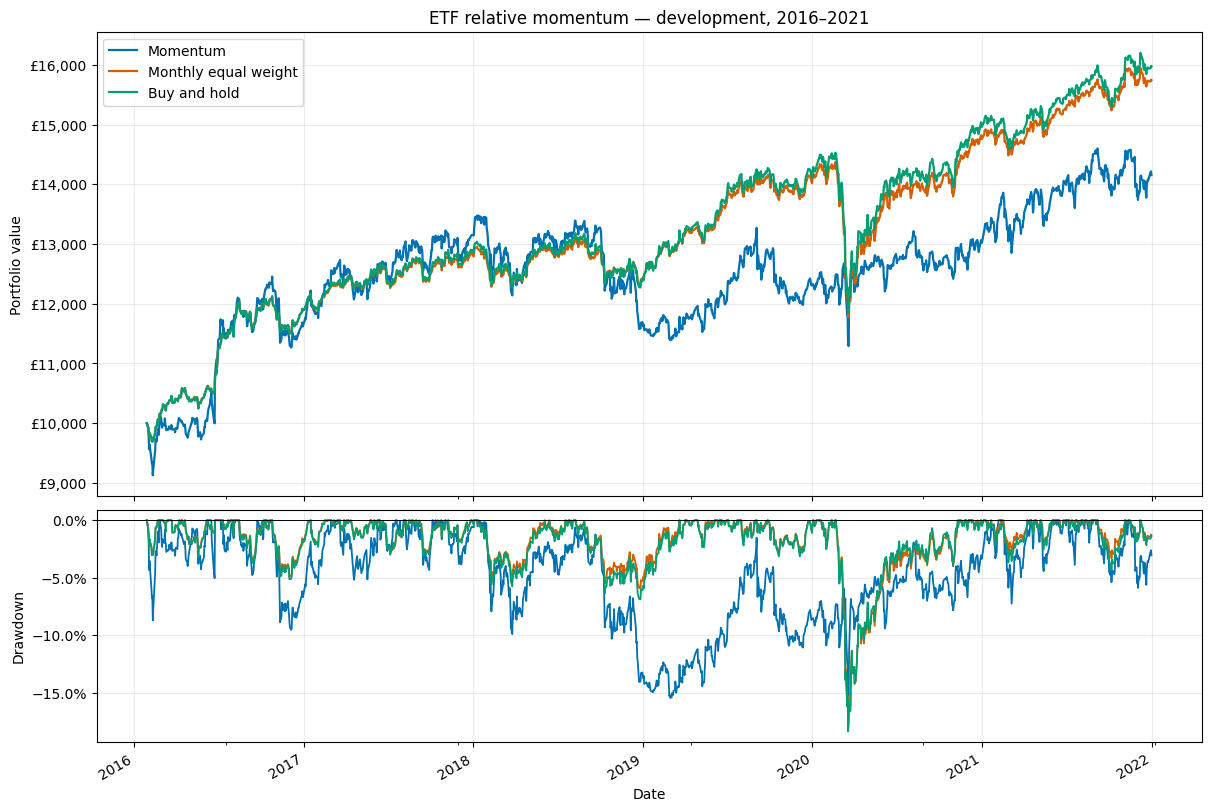

,cagr_pct,annualised_vol_pct,max_drawdown_pct,total_cost_gbp
portfolio,,,,
momentum,6.05,12.80,-16.22,490.17
equal_weight,7.97,7.94,-18.07,33.57
buy_and_hold,8.24,8.55,-18.38,9.99


In [17]:
import etf_plotting
import etf_research

development_equity = pd.DataFrame({
    name: result["daily"]["nav_close"]
    for name, result in development_results.items()
}).rename(columns={
    "momentum": "Momentum",
    "equal_weight": "Monthly equal weight",
    "buy_and_hold": "Buy and hold",
})

fig, axes = etf_plotting.plot_equity_and_drawdown(
    development_equity,
    initial_capital_gbp=BACKTEST_SETTINGS["initial_capital_gbp"],
    start_date=dev_calendar.index[0],
    title="ETF relative momentum — development, 2016–2021",
)

development_metrics = etf_research.summarise_portfolios(
    development_results,
    initial_capital_gbp=BACKTEST_SETTINGS["initial_capital_gbp"],
)

display(development_metrics[[
    "cagr_pct",
    "annualised_vol_pct",
    "max_drawdown_pct",
    "total_cost_gbp",
]].round(2))

In [18]:
import etf_momentum_validation

dev_end = pd.Timestamp(PERIODS["development"][1])

sweep_summary, sweep_results = (
    etf_momentum_validation.run_parameter_sweep(
        monthly_prices.loc[monthly_prices.index < dev_end],
        adjusted_open.loc[dev_price_mask],
        adjusted_close.loc[dev_price_mask],
        dev_calendar,
        common_eligibility,
        lookbacks=(3, 6, 9, 12),
        top_ns=(1, 3, 5, 8),
        **BACKTEST_SETTINGS,
    )
)

display(
    sweep_summary[[
        "lookback_months",
        "top_n",
        "cagr_pct",
        "annualised_vol_pct",
        "sharpe_zero_rf",
        "max_drawdown_pct",
        "total_cost_gbp",
    ]]
    .sort_values("sharpe_zero_rf", ascending=False)
    .round(3)
)

1/16: 3 months, top 1
2/16: 3 months, top 3
3/16: 3 months, top 5
4/16: 3 months, top 8
5/16: 6 months, top 1
6/16: 6 months, top 3
7/16: 6 months, top 5
8/16: 6 months, top 8
9/16: 9 months, top 1
10/16: 9 months, top 3
11/16: 9 months, top 5
12/16: 9 months, top 8
13/16: 12 months, top 1
14/16: 12 months, top 3
15/16: 12 months, top 5
16/16: 12 months, top 8


,lookback_months,top_n,cagr_pct,annualised_vol_pct,sharpe_zero_rf,max_drawdown_pct,total_cost_gbp
configuration_id,,,,,,,
3,3,8,7.689,9.309,0.839,-12.190,526.843
11,9,8,7.403,9.250,0.815,-16.361,350.454
9,9,3,9.192,12.159,0.781,-13.432,578.798
7,6,8,7.017,9.319,0.771,-21.648,391.815
10,9,5,7.769,10.691,0.750,-14.050,499.411
15,12,8,5.885,9.246,0.662,-15.161,308.838
6,6,5,6.747,11.021,0.645,-28.308,554.807
14,12,5,6.762,11.123,0.641,-16.078,423.567
2,3,5,5.823,10.614,0.584,-15.201,696.083


In [19]:
benchmark_net = development_results["equal_weight"]["daily"]["net_return"]

sweep_returns = pd.DataFrame({
    config_id: result["daily"]["net_return"]
    for config_id, result in sweep_results.items()
})

assert sweep_returns.index.equals(benchmark_net.index)
assert sweep_returns.notna().all().all()

development_excess = sweep_returns.sub(benchmark_net, axis=0)

sweep_comparison = sweep_summary.copy()
sweep_comparison["mean_net_excess_bps"] = (
    development_excess.mean() * 10_000
)
sweep_comparison["correlation_to_benchmark"] = (
    sweep_returns.corrwith(benchmark_net)
)

display(
    sweep_comparison[[
        "lookback_months",
        "top_n",
        "sharpe_zero_rf",
        "mean_net_excess_bps",
        "correlation_to_benchmark",
    ]]
    .sort_values("mean_net_excess_bps", ascending=False)
    .round(3)
)

,lookback_months,top_n,sharpe_zero_rf,mean_net_excess_bps,correlation_to_benchmark
configuration_id,,,,,
9,9,3,0.781,0.611,0.653
10,9,5,0.750,0.027,0.702
0,3,1,0.522,-0.016,0.463
3,3,8,0.839,-0.057,0.733
11,9,8,0.815,-0.164,0.798
7,6,8,0.771,-0.304,0.775
14,12,5,0.641,-0.326,0.698
6,6,5,0.645,-0.335,0.738
13,12,3,0.520,-0.513,0.618


In [20]:
equity_src = str(PROJECT_DIR.parent / "equity_momentum" / "src")
if equity_src not in sys.path:
    sys.path.insert(0, equity_src)

import momentum_validation

sweep_tests = momentum_validation.bootstrap_sweep_excess(
    development_excess,
    block_length=63,
    n_bootstrap=10_000,
    alpha=0.05,
    seed=42,
)

sweep_test_summary = sweep_summary[
    ["lookback_months", "top_n"]
].join(sweep_tests)

display(
    sweep_test_summary
    .sort_values("p_one_sided")
    .round(4)
)

print(
    "Configurations passing Holm correction:",
    int(sweep_tests["reject_holm"].sum()),
)

,lookback_months,top_n,mean_daily_net_excess_bps,lower_ci_bps,upper_ci_bps,p_one_sided,p_holm,reject_holm
configuration_id,,,,,,,,
9,9,3,0.6114,-1.8894,2.9375,0.2973,1.0,False
10,9,5,0.0267,-1.9957,1.9791,0.4716,1.0,False
0,3,1,-0.0157,-3.1281,3.3042,0.5066,1.0,False
3,3,8,-0.0569,-1.7315,1.5392,0.5172,1.0,False
11,9,8,-0.1643,-1.4535,1.1634,0.5928,1.0,False
6,6,5,-0.3354,-2.2376,1.5952,0.6343,1.0,False
14,12,5,-0.3257,-2.1308,1.4252,0.6343,1.0,False
7,6,8,-0.3041,-1.9374,1.3021,0.6409,1.0,False
13,12,3,-0.5127,-3.0992,1.9677,0.6460,1.0,False


Configurations passing Holm correction: 0


In [21]:
import momentum_walk_forward

WF_RULES = {
    "training_years": 3,
    "selection_metric": "sharpe_zero_rf",
    "refit_frequency": "annual",
    "tie_break": "lowest_configuration_id",
}

wf_development_returns = sweep_returns.loc["2017-01-01":].copy()

wf_development_folds = (
    momentum_walk_forward.build_annual_walk_forward_folds(
        wf_development_returns,
        analysis_schedule,
        training_years=WF_RULES["training_years"],
    )
)

display(wf_development_folds)

,train_start,train_end,selection_date,test_start,test_end,train_sessions,test_sessions
fold,,,,,,,
0,2017-01-03,2019-12-31,2019-12-31,2020-01-02,2020-12-31,758,254
1,2018-01-02,2020-12-31,2020-12-31,2021-01-04,2021-12-31,760,253


In [22]:
wf_parameter_grid = sweep_summary[
    ["lookback_months", "top_n"]
].sort_index()

wf_development_choices = (
    momentum_walk_forward.select_walk_forward_configurations(
        wf_development_returns.sort_index(axis=1),
        wf_development_folds,
        wf_parameter_grid,
        WF_RULES,
    )
)

display(
    wf_development_choices[[
        "train_start",
        "train_end",
        "test_start",
        "configuration_id",
        "lookback_months",
        "top_n",
        "training_sharpe",
    ]].round(3)
)

,train_start,train_end,test_start,configuration_id,lookback_months,top_n,training_sharpe
fold,,,,,,,
0,2017-01-03,2019-12-31,2020-01-02,0,3,1,0.571
1,2018-01-02,2020-12-31,2021-01-04,0,3,1,0.556


In [23]:
wf_target_parts = []

for choice in wf_development_choices.itertuples():
    fold_calendar = dev_calendar.loc[
        dev_calendar["execution_date"].between(
            choice.test_start, choice.test_end
        )
    ]

    scores = etf_momentum_features.build_momentum_scores(
        monthly_prices.loc[:choice.test_end],
        lookback_months=int(choice.lookback_months),
    ).loc[fold_calendar.index]

    eligible = common_eligibility.loc[
        scores.index, scores.columns
    ]

    assert not (eligible & scores.isna()).any().any()

    targets = etf_momentum_backtest.build_target_weights(
        scores.where(eligible),
        top_n=int(choice.top_n),
    )

    targets.index = pd.DatetimeIndex(
        fold_calendar["execution_date"],
        name="Date",
    )

    assert fold_calendar.index[0] == choice.selection_date
    assert targets.index[0] == choice.test_start

    wf_target_parts.append(targets)

wf_development_targets = pd.concat(wf_target_parts).sort_index()

expected_dates = dev_execution_dates[
    (dev_execution_dates >= wf_development_choices["test_start"].min())
    & (dev_execution_dates <= wf_development_choices["test_end"].max())
]

assert wf_development_targets.index.is_unique
assert wf_development_targets.index.equals(expected_dates)

print("Scheduled rebalances:", len(wf_development_targets))
display(wf_development_targets.head())


Scheduled rebalances: 24


ticker,IUSA,ISF,IEUX,IJPN,IEEM,CPJ1,MIDD,WLDS,IGLS,IGLT,...,INXG,IGTM,XGSG,SLXX,CRHG,GHYS,IWDP,SGLN,CMOP,CASH
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-02-03,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-03-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2020-04-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2020-05-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [24]:
wf_start = wf_development_targets.index[0]
wf_end = wf_development_choices["test_end"].max()

wf_portfolio_targets = {
    "walk_forward": wf_development_targets,
    "equal_weight": benchmark_execution_weights.loc[
        wf_development_targets.index
    ],
    "buy_and_hold": benchmark_execution_weights.loc[[wf_start]],
}

wf_development_results = {
    name: etf_momentum_backtest.run_backtest(
        adjusted_open.loc[wf_start:wf_end],
        adjusted_close.loc[wf_start:wf_end],
        targets,
        **BACKTEST_SETTINGS,
    )
    for name, targets in wf_portfolio_targets.items()
}

wf_development_metrics = etf_research.summarise_portfolios(
    wf_development_results,
    initial_capital_gbp=BACKTEST_SETTINGS["initial_capital_gbp"],
)

wf_daily_returns = pd.DataFrame({
    name: result["daily"]["net_return"]
    for name, result in wf_development_results.items()
})

wf_development_metrics["sharpe_zero_rf"] = (
    252 ** 0.5
    * wf_daily_returns.mean()
    / wf_daily_returns.std(ddof=1).replace(0, float("nan"))
)

display(wf_development_metrics[[
    "final_value_gbp",
    "cagr_pct",
    "annualised_vol_pct",
    "sharpe_zero_rf",
    "max_drawdown_pct",
    "total_cost_gbp",
]].round(3))

,final_value_gbp,cagr_pct,annualised_vol_pct,sharpe_zero_rf,max_drawdown_pct,total_cost_gbp
portfolio,,,,,,
walk_forward,10731.466,3.595,16.864,0.292,-16.186,347.630
equal_weight,11196.989,5.820,9.972,0.614,-18.070,16.194
buy_and_hold,11250.213,6.071,9.791,0.647,-17.596,9.990


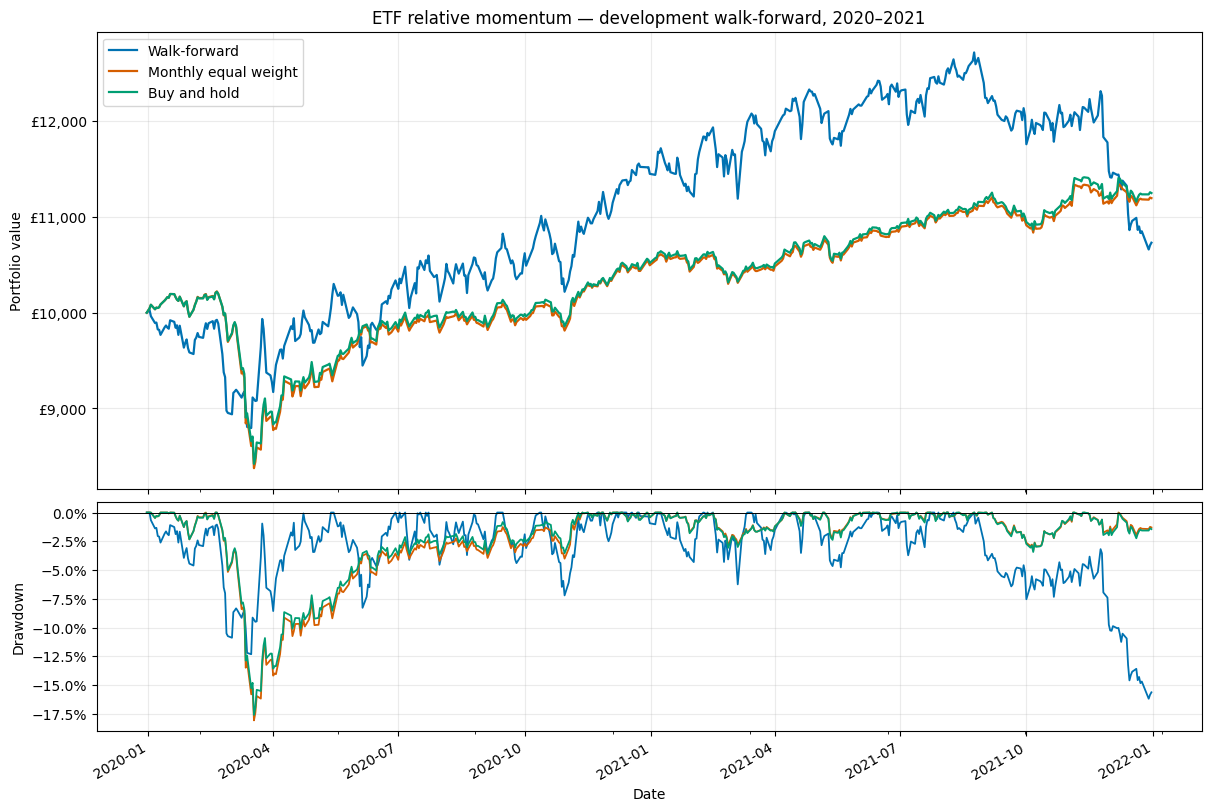

In [25]:
wf_development_equity = pd.DataFrame({
    name: result["daily"]["nav_close"]
    for name, result in wf_development_results.items()
}).rename(columns={
    "walk_forward": "Walk-forward",
    "equal_weight": "Monthly equal weight",
    "buy_and_hold": "Buy and hold",
})

fig, axes = etf_plotting.plot_equity_and_drawdown(
    wf_development_equity,
    initial_capital_gbp=BACKTEST_SETTINGS["initial_capital_gbp"],
    start_date=wf_development_choices["selection_date"].min(),
    title="ETF relative momentum — development walk-forward, 2020–2021",
)

In [26]:
validation_start, validation_end = map(
    pd.Timestamp, PERIODS["validation"]
)

wf_history_calendar = execution_calendar.loc[
    execution_calendar["execution_date"].lt(validation_end)
]

wf_history_mask = (
    (adjusted_open.index >=
     wf_history_calendar["execution_date"].min())
    & (adjusted_open.index < validation_end)
)

wf_history_summary, wf_history_results = (
    etf_momentum_validation.run_parameter_sweep(
        monthly_prices.loc[monthly_prices.index < validation_end],
        adjusted_open.loc[wf_history_mask],
        adjusted_close.loc[wf_history_mask],
        wf_history_calendar,
        common_eligibility,
        lookbacks=(3, 6, 9, 12),
        top_ns=(1, 3, 5, 8),
        **BACKTEST_SETTINGS,
    )
)

wf_history_returns = pd.DataFrame({
    config_id: result["daily"]["net_return"]
    for config_id, result in wf_history_results.items()
}).sort_index(axis=1)

# Extending the history must preserve the earlier results.
pd.testing.assert_frame_equal(
    wf_history_returns.loc[sweep_returns.index],
    sweep_returns.sort_index(axis=1),
    check_exact=False,
    rtol=1e-12,
    atol=1e-12,
)

print("Configurations:", wf_history_returns.shape[1])
print(
    "Return history:",
    wf_history_returns.index.min().date(),
    "to",
    wf_history_returns.index.max().date(),
)

1/16: 3 months, top 1
2/16: 3 months, top 3
3/16: 3 months, top 5
4/16: 3 months, top 8
5/16: 6 months, top 1
6/16: 6 months, top 3
7/16: 6 months, top 5
8/16: 6 months, top 8
9/16: 9 months, top 1
10/16: 9 months, top 3
11/16: 9 months, top 5
12/16: 9 months, top 8
13/16: 12 months, top 1
14/16: 12 months, top 3
15/16: 12 months, top 5
16/16: 12 months, top 8
Configurations: 16
Return history: 2016-02-01 to 2023-12-29


In [27]:
wf_history_folds = (
    momentum_walk_forward.build_annual_walk_forward_folds(
        wf_history_returns.loc["2017-01-01":],
        analysis_schedule,
        training_years=WF_RULES["training_years"],
    )
)

wf_validation_folds = wf_history_folds.loc[
    (wf_history_folds["test_start"] >= validation_start)
    & (wf_history_folds["test_start"] < validation_end)
].copy()

wf_validation_choices = (
    momentum_walk_forward.select_walk_forward_configurations(
        wf_history_returns,
        wf_validation_folds,
        wf_parameter_grid,
        WF_RULES,
    )
)

display(
    wf_validation_choices[[
        "train_start",
        "train_end",
        "test_start",
        "configuration_id",
        "lookback_months",
        "top_n",
        "training_sharpe",
    ]].round(3)
)

,train_start,train_end,test_start,configuration_id,lookback_months,top_n,training_sharpe
fold,,,,,,,
2,2019-01-02,2021-12-31,2022-01-04,3,3,8,0.987
3,2020-01-02,2022-12-30,2023-01-03,9,9,3,0.660


In [28]:
validation_calendar = execution_calendar.loc[
    execution_calendar["period"].eq("validation")
]

wf_validation_target_parts = []

for choice in wf_validation_choices.itertuples():
    fold_calendar = validation_calendar.loc[
        validation_calendar["execution_date"].between(
            choice.test_start, choice.test_end
        )
    ]

    scores = etf_momentum_features.build_momentum_scores(
        monthly_prices.loc[:choice.test_end],
        lookback_months=int(choice.lookback_months),
    ).loc[fold_calendar.index]

    eligible = common_eligibility.loc[
        scores.index, scores.columns
    ]

    assert not (eligible & scores.isna()).any().any()

    targets = etf_momentum_backtest.build_target_weights(
        scores.where(eligible),
        top_n=int(choice.top_n),
    )

    targets.index = pd.DatetimeIndex(
        fold_calendar["execution_date"],
        name="Date",
    )

    assert fold_calendar.index[0] == choice.selection_date
    assert targets.index[0] == choice.test_start

    wf_validation_target_parts.append(targets)

wf_validation_targets = pd.concat(
    wf_validation_target_parts
).sort_index()

validation_execution_dates = pd.DatetimeIndex(
    validation_calendar["execution_date"],
    name="Date",
)

assert wf_validation_targets.index.is_unique
assert wf_validation_targets.index.equals(validation_execution_dates)

holdings_per_rebalance = (
    wf_validation_targets.drop(columns="CASH").gt(0).sum(axis=1)
)

print("Scheduled rebalances:", len(wf_validation_targets))
display(
    holdings_per_rebalance
    .groupby(holdings_per_rebalance.index.year)
    .agg(["min", "max"])
    .rename_axis("year")
)

Scheduled rebalances: 24


,min,max
year,,
2022,8,8
2023,3,3


In [29]:
wf_validation_start = wf_validation_targets.index[0]
wf_validation_end = wf_validation_choices["test_end"].max()

wf_validation_portfolio_targets = {
    "walk_forward": wf_validation_targets,
    "equal_weight": benchmark_execution_weights.loc[
        wf_validation_targets.index
    ],
    "buy_and_hold": benchmark_execution_weights.loc[
        [wf_validation_start]
    ],
}

wf_validation_results = {
    name: etf_momentum_backtest.run_backtest(
        adjusted_open.loc[wf_validation_start:wf_validation_end],
        adjusted_close.loc[wf_validation_start:wf_validation_end],
        targets,
        **BACKTEST_SETTINGS,
    )
    for name, targets in wf_validation_portfolio_targets.items()
}

wf_validation_returns = pd.DataFrame({
    name: result["daily"]["net_return"]
    for name, result in wf_validation_results.items()
})

wf_validation_metrics = etf_research.summarise_portfolios(
    wf_validation_results,
    initial_capital_gbp=BACKTEST_SETTINGS["initial_capital_gbp"],
)

wf_validation_metrics["sharpe_zero_rf"] = (
    252 ** 0.5
    * wf_validation_returns.mean()
    / wf_validation_returns.std(ddof=1).replace(0, float("nan"))
)

display(wf_validation_metrics[[
    "final_value_gbp",
    "cagr_pct",
    "annualised_vol_pct",
    "sharpe_zero_rf",
    "max_drawdown_pct",
    "total_cost_gbp",
]].round(3))

,final_value_gbp,cagr_pct,annualised_vol_pct,sharpe_zero_rf,max_drawdown_pct,total_cost_gbp
portfolio,,,,,,
walk_forward,8982.826,-5.261,10.497,-0.461,-15.758,148.934
equal_weight,9441.481,-2.854,8.160,-0.314,-15.867,14.525
buy_and_hold,9477.509,-2.667,7.871,-0.304,-14.653,9.990


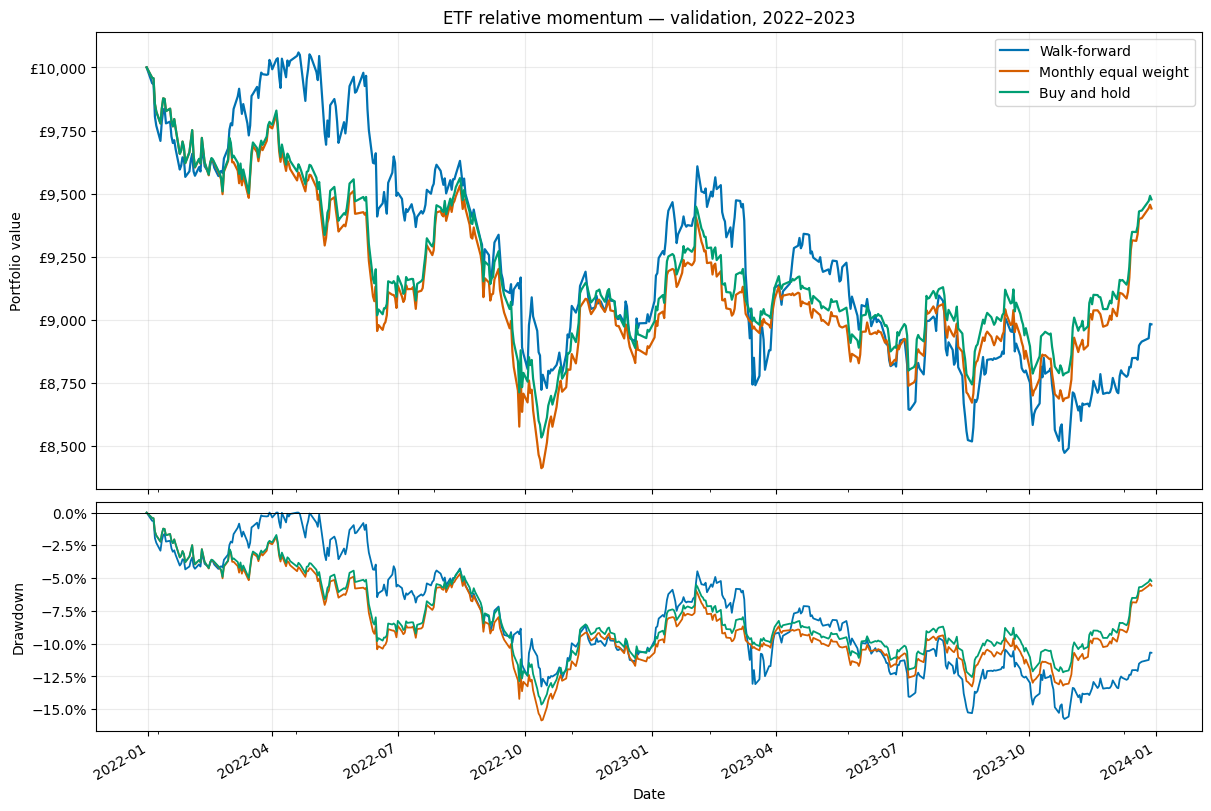

Annual net returns (%)


,Walk-forward,Monthly equal weight,Buy and hold
year,,,
2022,-10.07,-11.10,-10.45
2023,-0.12,6.21,5.84


In [30]:
wf_labels = {
    "walk_forward": "Walk-forward",
    "equal_weight": "Monthly equal weight",
    "buy_and_hold": "Buy and hold",
}

wf_validation_equity = pd.DataFrame({
    name: result["daily"]["nav_close"]
    for name, result in wf_validation_results.items()
}).rename(columns=wf_labels)

fig, axes = etf_plotting.plot_equity_and_drawdown(
    wf_validation_equity,
    initial_capital_gbp=BACKTEST_SETTINGS["initial_capital_gbp"],
    start_date=wf_validation_choices["selection_date"].min(),
    title="ETF relative momentum — validation, 2022–2023",
)

wf_validation_annual_returns = 100 * (
    (1 + wf_validation_returns)
    .groupby(wf_validation_returns.index.year)
    .prod()
    - 1
)

print("Annual net returns (%)")
display(
    wf_validation_annual_returns
    .rename(columns=wf_labels)
    .rename_axis("year")
    .round(2)
)

In [31]:
final_start, final_end = map(
    pd.Timestamp, PERIODS["final_evaluation"]
)

final_calendar = execution_calendar.loc[
    execution_calendar["period"].eq("final_evaluation")
]

final_price_mask = (
    (adjusted_open.index >= final_start)
    & (adjusted_open.index < final_end)
)

excluded_quotes = pd.DataFrame({
    ticker: frame["quote_excluded"]
    for ticker, frame in aligned_histories.items()
}).reindex(
    index=adjusted_open.index,
    columns=adjusted_open.columns,
)

final_mark_open, final_mark_close, final_stale = (
    etf_data.prepare_valuation_marks(
        adjusted_open.loc[final_price_mask],
        adjusted_close.loc[final_price_mask],
        excluded_quotes.loc[final_price_mask],
        execution_dates=final_calendar["execution_date"],
    )
)

valuation_open = adjusted_open.copy()
valuation_close = adjusted_close.copy()

valuation_open.loc[final_price_mask] = final_mark_open
valuation_close.loc[final_price_mask] = final_mark_close

display(
    final_stale.loc[
        final_stale.any(axis=1),
        final_stale.any(axis=0),
    ]
)

ticker,IJPN,WLDS,CMOP
Date,,,
2025-10-24,True,True,True


In [32]:
wf_full_calendar = execution_calendar.loc[
    execution_calendar["execution_date"] < final_end
]

wf_full_price_mask = (
    (valuation_open.index >=
     wf_full_calendar["execution_date"].min())
    & (valuation_open.index < final_end)
)

wf_full_summary, wf_full_results = (
    etf_momentum_validation.run_parameter_sweep(
        monthly_prices.loc[monthly_prices.index < final_end],
        valuation_open.loc[wf_full_price_mask],
        valuation_close.loc[wf_full_price_mask],
        wf_full_calendar,
        common_eligibility,
        lookbacks=(3, 6, 9, 12),
        top_ns=(1, 3, 5, 8),
        **BACKTEST_SETTINGS,
    )
)

wf_full_returns = pd.DataFrame({
    config_id: result["daily"]["net_return"]
    for config_id, result in wf_full_results.items()
}).sort_index(axis=1)

# Confirm all returns through 2023 are reproduced.
pd.testing.assert_frame_equal(
    wf_full_returns.loc[wf_history_returns.index],
    wf_history_returns,
    check_exact=False,
    rtol=1e-12,
    atol=1e-12,
)

print("Configurations:", wf_full_returns.shape[1])
print(
    "Return history:",
    wf_full_returns.index.min().date(),
    "to",
    wf_full_returns.index.max().date(),
)

1/16: 3 months, top 1
2/16: 3 months, top 3
3/16: 3 months, top 5
4/16: 3 months, top 8
5/16: 6 months, top 1
6/16: 6 months, top 3
7/16: 6 months, top 5
8/16: 6 months, top 8
9/16: 9 months, top 1
10/16: 9 months, top 3
11/16: 9 months, top 5
12/16: 9 months, top 8
13/16: 12 months, top 1
14/16: 12 months, top 3
15/16: 12 months, top 5
16/16: 12 months, top 8
Configurations: 16
Return history: 2016-02-01 to 2026-08-28


In [33]:
wf_full_folds = (
    momentum_walk_forward.build_annual_walk_forward_folds(
        wf_full_returns.loc["2017-01-01":],
        analysis_schedule,
        training_years=WF_RULES["training_years"],
    )
)

wf_final_folds = wf_full_folds.loc[
    (wf_full_folds["test_start"] >= final_start)
    & (wf_full_folds["test_start"] < final_end)
].copy()

wf_final_choices = (
    momentum_walk_forward.select_walk_forward_configurations(
        wf_full_returns,
        wf_final_folds,
        wf_parameter_grid,
        WF_RULES,
    )
)

display(
    wf_final_choices[[
        "train_start",
        "train_end",
        "test_start",
        "test_end",
        "configuration_id",
        "lookback_months",
        "top_n",
        "training_sharpe",
    ]].round(3)
)

,train_start,train_end,test_start,test_end,configuration_id,lookback_months,top_n,training_sharpe
fold,,,,,,,,
4,2021-01-04,2023-12-29,2024-01-02,2024-12-31,14,12,5,0.625
5,2022-01-04,2024-12-31,2025-01-02,2025-12-31,8,9,1,0.648
6,2023-01-03,2025-12-31,2026-01-02,2026-08-28,8,9,1,1.462


In [34]:
wf_final_target_parts = []

for choice in wf_final_choices.itertuples():
    fold_calendar = final_calendar.loc[
        final_calendar["execution_date"].between(
            choice.test_start, choice.test_end
        )
    ]

    scores = etf_momentum_features.build_momentum_scores(
        monthly_prices.loc[:choice.test_end],
        lookback_months=int(choice.lookback_months),
    ).loc[fold_calendar.index]

    eligible = common_eligibility.loc[
        scores.index, scores.columns
    ]

    assert not (eligible & scores.isna()).any().any()

    targets = etf_momentum_backtest.build_target_weights(
        scores.where(eligible),
        top_n=int(choice.top_n),
    )

    targets.index = pd.DatetimeIndex(
        fold_calendar["execution_date"],
        name="Date",
    )

    assert fold_calendar.index[0] == choice.selection_date
    assert targets.index[0] == choice.test_start

    wf_final_target_parts.append(targets)

wf_final_targets = pd.concat(wf_final_target_parts).sort_index()

final_execution_dates = pd.DatetimeIndex(
    final_calendar["execution_date"],
    name="Date",
)

assert wf_final_targets.index.is_unique
assert wf_final_targets.index.equals(final_execution_dates)

final_holdings_per_rebalance = (
    wf_final_targets.drop(columns="CASH").gt(0).sum(axis=1)
)

display(
    final_holdings_per_rebalance
    .groupby(final_holdings_per_rebalance.index.year)
    .agg(["count", "min", "max"])
    .rename(columns={"count": "rebalances"})
    .rename_axis("year")
)

,rebalances,min,max
year,,,
2024,12,5,5
2025,12,1,1
2026,8,1,1


In [35]:
wf_final_start = wf_final_targets.index[0]
wf_final_end = wf_final_choices["test_end"].max()

wf_final_portfolio_targets = {
    "walk_forward": wf_final_targets,
    "equal_weight": benchmark_execution_weights.loc[
        wf_final_targets.index
    ],
    "buy_and_hold": benchmark_execution_weights.loc[
        [wf_final_start]
    ],
}

wf_final_results = {
    name: etf_momentum_backtest.run_backtest(
        valuation_open.loc[wf_final_start:wf_final_end],
        valuation_close.loc[wf_final_start:wf_final_end],
        targets,
        **BACKTEST_SETTINGS,
    )
    for name, targets in wf_final_portfolio_targets.items()
}

wf_final_returns = pd.DataFrame({
    name: result["daily"]["net_return"]
    for name, result in wf_final_results.items()
})

wf_final_metrics = etf_research.summarise_portfolios(
    wf_final_results,
    initial_capital_gbp=BACKTEST_SETTINGS["initial_capital_gbp"],
)

wf_final_metrics["sharpe_zero_rf"] = (
    252 ** 0.5
    * wf_final_returns.mean()
    / wf_final_returns.std(ddof=1).replace(0, float("nan"))
)

display(wf_final_metrics[[
    "final_value_gbp",
    "cagr_pct",
    "annualised_vol_pct",
    "sharpe_zero_rf",
    "max_drawdown_pct",
    "total_cost_gbp",
]].round(3))

,final_value_gbp,cagr_pct,annualised_vol_pct,sharpe_zero_rf,max_drawdown_pct,total_cost_gbp
portfolio,,,,,,
walk_forward,17254.972,22.803,18.759,1.182,-26.061,178.844
equal_weight,12766.259,9.632,6.581,1.421,-8.242,16.322
buy_and_hold,12953.534,10.235,6.856,1.446,-8.305,9.990


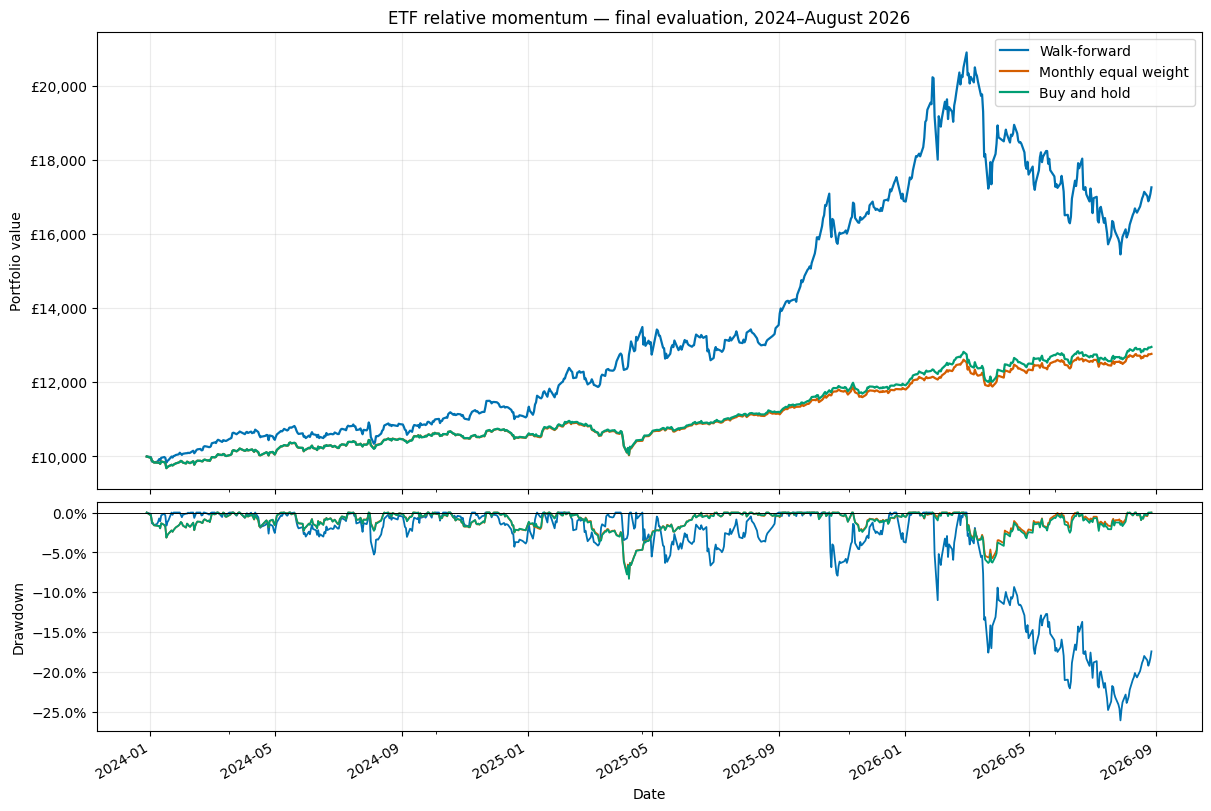

Net returns (%) — 2026 covers January to 28 August


,Walk-forward,Monthly equal weight,Buy and hold
year,,,
2024,10.84,5.40,5.47
2025,52.38,12.20,13.16
2026,2.16,7.96,8.53


In [36]:
wf_final_equity = pd.DataFrame({
    name: result["daily"]["nav_close"]
    for name, result in wf_final_results.items()
}).rename(columns=wf_labels)

fig, axes = etf_plotting.plot_equity_and_drawdown(
    wf_final_equity,
    initial_capital_gbp=BACKTEST_SETTINGS["initial_capital_gbp"],
    start_date=wf_final_choices["selection_date"].min(),
    title="ETF relative momentum — final evaluation, 2024–August 2026",
)

wf_final_annual_returns = 100 * (
    (1 + wf_final_returns)
    .groupby(wf_final_returns.index.year)
    .prod()
    - 1
)

print("Net returns (%) — 2026 covers January to 28 August")
display(
    wf_final_annual_returns
    .rename(columns=wf_labels)
    .rename_axis("year")
    .round(2)
)

In [37]:
final_strategy = wf_final_results["walk_forward"]

asset_values = final_strategy["holdings"].drop(columns="CASH")
asset_trades = final_strategy["trades"]

asset_gross_pnl = (
    asset_values
    - asset_values.shift(1, fill_value=0.0)
    - asset_trades
)

asset_costs = (
    asset_trades.abs()
    * BACKTEST_SETTINGS["cost_per_side_bps"]
    / 10_000
)

wf_final_asset_net_pnl = asset_gross_pnl - asset_costs

# Reconcile ETF costs and profits to the portfolio ledger.
np.testing.assert_allclose(
    asset_costs.sum(axis=1),
    final_strategy["daily"]["cost"],
    rtol=1e-10,
    atol=1e-8,
)

nav = final_strategy["daily"]["nav_close"]
previous_nav = nav.shift(
    1, fill_value=BACKTEST_SETTINGS["initial_capital_gbp"]
)

np.testing.assert_allclose(
    wf_final_asset_net_pnl.sum(axis=1),
    nav - previous_nav,
    rtol=1e-10,
    atol=1e-8,
)

wf_final_attribution = pd.DataFrame({
    "gross_pnl_gbp": asset_gross_pnl.sum(),
    "cost_gbp": asset_costs.sum(),
    "net_pnl_gbp": wf_final_asset_net_pnl.sum(),
}).join(universe[["research_exposure"]])

display(
    wf_final_attribution.loc[asset_trades.abs().sum().gt(0)]
    .sort_values("net_pnl_gbp", ascending=False)
    .round(2)
)

,gross_pnl_gbp,cost_gbp,net_pnl_gbp,research_exposure
ticker,,,,
SGLN,7253.80,29.37,7224.43,Physical gold
CMOP,853.15,51.25,801.90,Broad commodity futures
IUSA,521.48,4.69,516.79,US large-cap equities
IJPN,173.47,4.49,168.98,Japanese equities
MIDD,63.75,4.59,59.15,UK mid-cap equities
IEUX,49.11,8.33,40.79,Europe ex-UK equities
GHYS,2.27,4.12,-1.85,"Global high-yield corporate bonds, GBP hedged"
WLDS,6.20,12.78,-6.58,Developed-world small-cap equities
ISF,-3.43,4.33,-7.76,UK large-cap equities


In [38]:
wf_final_excess = (
    wf_final_returns["walk_forward"]
    - wf_final_returns["equal_weight"]
).to_frame("walk_forward")

wf_final_test = momentum_validation.bootstrap_sweep_excess(
    wf_final_excess,
    block_length=63,
    n_bootstrap=10_000,
    alpha=0.05,
    seed=42,
)

display(
    wf_final_test.rename_axis("strategy").round(4)
)

,mean_daily_net_excess_bps,lower_ci_bps,upper_ci_bps,p_one_sided,p_holm,reject_holm
strategy,,,,,,
walk_forward,5.0877,-2.4205,13.0929,0.0943,0.0943,False
